# Phase 2 — Tests statistiques : l'effet moyen des e-mails

La phase 1 a établi que la randomisation a fonctionné. Les écarts de résultats entre groupes sont donc des **effets causaux**. Reste à savoir s'ils sont **plus grands que le bruit** d'échantillonnage, et avec quelle précision on les connaît.

**L'estimand** : l'**effet moyen du traitement** (*Average Treatment Effect*, ATE).

$$ATE = \mathbb{E}[Y(1)] - \mathbb{E}[Y(0)]$$

où $Y(1)$ est le résultat d'un client s'il reçoit l'e-mail et $Y(0)$ s'il ne le reçoit pas. On n'observe jamais les deux pour un même client (c'est le *problème fondamental de l'inférence causale*). Mais grâce à la randomisation, la moyenne du groupe traité estime sans biais $\mathbb{E}[Y(1)]$, et celle du contrôle $\mathbb{E}[Y(0)]$. **L'ATE s'estime donc par une simple différence de moyennes.**

**Plan** :
1. Proportions (visite, conversion) : z-test de deux proportions.
2. Dépense : test de Welch, puis bootstrap pour s'affranchir de toute hypothèse sur la distribution.
3. Décomposer l'effet sur la dépense : plus d'acheteurs, ou des paniers plus gros ?
4. Comparaisons multiples : 9 tests en même temps.
5. Ajustement par covariables (régression / CUPED) : peut-on gagner en précision ?
6. Premier regard sur l'**hétérogénéité** de l'effet, qui motive la phase 4.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

df = pd.read_csv("../data/hillstrom.csv")

CONTROLE = "No E-Mail"
TRAITEMENTS = ["Mens E-Mail", "Womens E-Mail"]
METRIQUES = ["visit", "conversion", "spend"]
COULEURS = {"No E-Mail": "#8a8984", "Mens E-Mail": "#2a78d6", "Womens E-Mail": "#eb6834"}
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.color": "#e6e5e1", "grid.linewidth": 0.8, "axes.axisbelow": True,
                     "font.size": 10})

groupes = {g: df[df["segment"] == g] for g in [CONTROLE] + TRAITEMENTS}
{g: len(d) for g, d in groupes.items()}

{'No E-Mail': 21306, 'Mens E-Mail': 21307, 'Womens E-Mail': 21387}

## 1. Proportions : le z-test de deux proportions

Pour une variable 0/1 (visite, conversion), la moyenne d'un groupe est une proportion $\hat p$, et sa variance d'échantillonnage vaut $\hat p(1-\hat p)/n$.

**Statistique de test** (sous $H_0 : p_T = p_C$, on estime une proportion commune $\hat p$ en regroupant les deux groupes) :

$$z = \frac{\hat p_T - \hat p_C}{\sqrt{\hat p(1-\hat p)\left(\frac{1}{n_T} + \frac{1}{n_C}\right)}}$$

Par le théorème central limite, $z$ suit approximativement une loi normale centrée réduite sous $H_0$, d'où la p-value bilatérale $2 \times P(Z > |z|)$.

**Intervalle de confiance à 95 %** de la différence : cette fois **sans** regrouper, puisqu'on ne suppose plus $H_0$.

$$(\hat p_T - \hat p_C) \pm 1{,}96 \sqrt{\frac{\hat p_T(1-\hat p_T)}{n_T} + \frac{\hat p_C(1-\hat p_C)}{n_C}}$$

On le calcule d'abord **à la main** pour voir chaque ingrédient, puis on vérifie avec `statsmodels`.

In [2]:
def z_test_proportions(x_traite, x_controle):
    n_t, n_c = len(x_traite), len(x_controle)
    p_t, p_c = x_traite.mean(), x_controle.mean()
    p_commun = (x_traite.sum() + x_controle.sum()) / (n_t + n_c)
    z = (p_t - p_c) / np.sqrt(p_commun * (1 - p_commun) * (1 / n_t + 1 / n_c))
    p_value = 2 * stats.norm.sf(abs(z))
    se = np.sqrt(p_t * (1 - p_t) / n_t + p_c * (1 - p_c) / n_c)
    diff = p_t - p_c
    return {"contrôle": p_c, "traité": p_t, "différence": diff,
            "IC95 bas": diff - 1.96 * se, "IC95 haut": diff + 1.96 * se,
            "lift relatif": diff / p_c, "z": z, "p-value": p_value}

lignes = []
for g in TRAITEMENTS:
    for m in ["visit", "conversion"]:
        lignes.append({"traitement": g, "métrique": m,
                       **z_test_proportions(groupes[g][m], groupes[CONTROLE][m])})
tests_proportions = pd.DataFrame(lignes).set_index(["traitement", "métrique"])
tests_proportions.style.format({"contrôle": "{:.3%}", "traité": "{:.3%}", "différence": "{:+.3%}",
                                "IC95 bas": "{:+.3%}", "IC95 haut": "{:+.3%}",
                                "lift relatif": "{:+.0%}", "z": "{:.2f}", "p-value": "{:.1e}"})

In [3]:
from statsmodels.stats.proportion import proportions_ztest

# Vérification avec statsmodels sur un cas : e-mail Hommes, conversion
t, c = groupes["Mens E-Mail"]["conversion"], groupes[CONTROLE]["conversion"]
z_sm, p_sm = proportions_ztest(count=[t.sum(), c.sum()], nobs=[len(t), len(c)])
print(f"statsmodels : z = {z_sm:.4f}, p = {p_sm:.3e}")
print(f"à la main   : z = {tests_proportions.loc[('Mens E-Mail', 'conversion'), 'z']:.4f}, "
      f"p = {tests_proportions.loc[('Mens E-Mail', 'conversion'), 'p-value']:.3e}")

statsmodels : z = 7.3851, p = 1.523e-13
à la main   : z = 7.3851, p = 1.523e-13


**Lecture** :
- **Visite** : +7,7 points pour l'e-mail Hommes (10,6 % → 18,3 %, soit +72 % en relatif) et +4,5 points pour l'e-mail Femmes. Les z dépassent 14 et les p-values sont astronomiquement petites : aucun doute.
- **Conversion** : +0,68 point pour l'e-mail Hommes, ce qui **double** quasiment le taux (+119 %), et +0,31 point pour l'e-mail Femmes (+54 %). Les deux sont très significatifs.
- **Attention à l'échelle** : l'IC de la conversion pour l'e-mail Femmes va de +0,15 à +0,47 point, une incertitude **relative** énorme (du simple au triple), alors que l'effet est « hautement significatif ». Significatif ne veut pas dire précis. La phase 3 explique pourquoi les événements rares coûtent si cher en échantillon.

## 2. La dépense : test de Welch

`spend` n'est pas binaire : on compare deux moyennes avec un **test t**.

**Pourquoi Welch plutôt que le test t de Student classique** : Student suppose des variances égales dans les deux groupes. Welch ne le suppose pas : il utilise $\sqrt{s_T^2/n_T + s_C^2/n_C}$ comme erreur standard et ajuste les degrés de liberté. C'est le choix par défaut recommandé, car il ne coûte presque rien quand les variances sont égales et protège quand elles ne le sont pas.

**Mais `spend` est très loin d'une loi normale** (99 % de zéros, queue jusqu'à 499 $). Le test t est-il encore valide ? Il ne suppose pas que *les données* sont normales, mais que *la moyenne de l'échantillon* l'est. Par le théorème central limite, c'est vrai pour n assez grand. Avec n ≈ 21 000 par groupe, c'est très probablement le cas. On le **vérifiera** par bootstrap juste après plutôt que de le croire sur parole.

In [4]:
lignes = []
for g in TRAITEMENTS:
    t, c = groupes[g]["spend"], groupes[CONTROLE]["spend"]
    res = stats.ttest_ind(t, c, equal_var=False)
    ic = res.confidence_interval(0.95)
    lignes.append({"traitement": g, "contrôle ($)": c.mean(), "traité ($)": t.mean(),
                   "différence ($)": t.mean() - c.mean(), "IC95 bas": ic.low, "IC95 haut": ic.high,
                   "lift relatif": (t.mean() - c.mean()) / c.mean(), "t": res.statistic, "p-value": res.pvalue})
tests_welch = pd.DataFrame(lignes).set_index("traitement")
tests_welch.style.format({"contrôle ($)": "{:.3f}", "traité ($)": "{:.3f}", "différence ($)": "{:+.3f}",
                          "IC95 bas": "{:+.3f}", "IC95 haut": "{:+.3f}", "lift relatif": "{:+.0%}",
                          "t": "{:.2f}", "p-value": "{:.1e}"})

,contrôle ($),traité ($),différence ($),IC95 bas,IC95 haut,lift relatif,t,p-value
traitement,,,,,,,,
Mens E-Mail,0.653,1.423,+0.770,+0.485,+1.055,+118%,5.30,1.2e-07
Womens E-Mail,0.653,1.077,+0.424,+0.169,+0.680,+65%,3.26,1.1e-03


### Vérification par bootstrap

**L'idée du bootstrap** : on ne connaît pas la loi d'échantillonnage de la différence de moyennes, mais on peut la **simuler**. On traite chaque échantillon observé comme s'il était la population, on y retire n clients **avec remise**, on recalcule la différence, et on répète des milliers de fois. La dispersion de ces différences simulées approxime la variabilité d'échantillonnage réelle.

**Intervalle percentile** : les quantiles 2,5 % et 97,5 % des différences simulées.

Si le bootstrap donne le même intervalle que Welch, c'est que le théorème central limite fait bien son travail malgré la forme de `spend`.

In [5]:
rng = np.random.default_rng(42)
N_BOOT = 5000

def bootstrap_diff_moyennes(x_traite, x_controle, n_boot=N_BOOT, rng=rng):
    x_t, x_c = np.asarray(x_traite), np.asarray(x_controle)
    diffs = np.empty(n_boot)
    for b in range(n_boot):
        diffs[b] = (rng.choice(x_t, size=len(x_t)).mean()
                    - rng.choice(x_c, size=len(x_c)).mean())
    return diffs

diffs_boot = {g: bootstrap_diff_moyennes(groupes[g]["spend"], groupes[CONTROLE]["spend"])
              for g in TRAITEMENTS}

pd.DataFrame({
    g: {"IC95 Welch": f"[{tests_welch.loc[g, 'IC95 bas']:.3f} ; {tests_welch.loc[g, 'IC95 haut']:.3f}]",
        "IC95 bootstrap": f"[{np.percentile(d, 2.5):.3f} ; {np.percentile(d, 97.5):.3f}]",
        "erreur standard Welch": f"{(tests_welch.loc[g, 'IC95 haut'] - tests_welch.loc[g, 'IC95 bas']) / (2 * 1.96):.4f}",
        "erreur standard bootstrap": f"{d.std():.4f}"}
    for g, d in diffs_boot.items()
}).T

,IC95 Welch,IC95 bootstrap,erreur standard Welch,erreur standard bootstrap
Mens E-Mail,[0.485 ; 1.055],[0.479 ; 1.049],0.1452,0.1443
Womens E-Mail,[0.169 ; 0.680],[0.166 ; 0.694],0.1303,0.1328


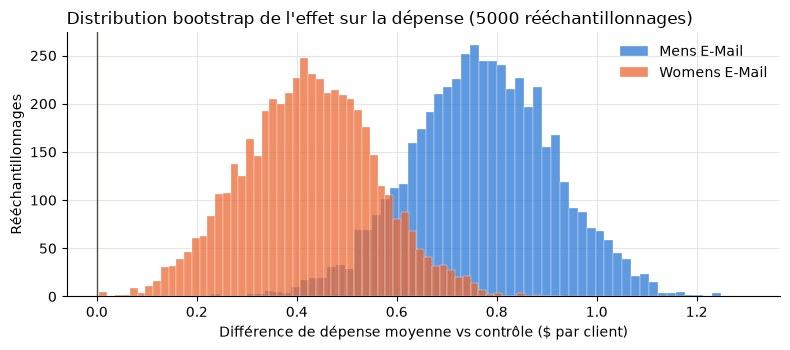

In [6]:
fig, ax = plt.subplots(figsize=(8, 3.6))
for g, d in diffs_boot.items():
    ax.hist(d, bins=60, color=COULEURS[g], alpha=0.75, label=g, edgecolor="white", linewidth=0.3)
ax.axvline(0, color="#52514e", linewidth=1)
ax.set_xlabel("Différence de dépense moyenne vs contrôle ($ par client)")
ax.set_ylabel("Rééchantillonnages")
ax.set_title(f"Distribution bootstrap de l'effet sur la dépense ({N_BOOT} rééchantillonnages)", loc="left")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("../docs/figures/02_bootstrap_spend.png", dpi=150)
plt.show()

**Lecture** : les intervalles bootstrap et Welch coïncident à quelques millièmes de $ près, et les distributions simulées ont bien une forme de cloche. Malgré les 99 % de zéros, le théorème central limite s'applique.

- E-mail Hommes : **+0,77 $ par client** (IC95 ≈ [0,49 ; 1,05]), soit +118 %.
- E-mail Femmes : **+0,42 $ par client** (IC95 ≈ [0,17 ; 0,68]), soit +65 %.
- Seule une poignée de rééchantillonnages de l'e-mail Femmes s'approche de 0 : l'effet est bien établi, mais son intervalle est large (du simple au quadruple).

## 3. Plus d'acheteurs ou des paniers plus gros ?

La dépense moyenne par client se décompose exactement :

$$\mathbb{E}[\text{spend}] = P(\text{conversion}) \times \mathbb{E}[\text{spend} \mid \text{conversion}]$$

L'e-mail peut donc agir par deux canaux : **convertir plus** de clients, ou faire **dépenser plus** ceux qui achètent. On compare le montant moyen *chez les acheteurs*.

⚠️ **Piège classique** : la conversion est elle-même affectée par le traitement. Comparer les acheteurs du groupe traité aux acheteurs du contrôle, c'est comparer **deux populations différentes**. Les acheteurs « gagnés » par l'e-mail ne sont pas forcément comparables à ceux qui auraient acheté de toute façon. Ce n'est plus une comparaison randomisée (**biais de sélection post-traitement**). On peut décrire ce qu'on voit, mais pas l'interpréter causalement au sens strict.

In [7]:
acheteurs = df[df["conversion"] == 1]
lignes = []
for g in TRAITEMENTS:
    t = acheteurs.loc[acheteurs["segment"] == g, "spend"]
    c = acheteurs.loc[acheteurs["segment"] == CONTROLE, "spend"]
    res = stats.ttest_ind(t, c, equal_var=False)
    lignes.append({"traitement": g, "acheteurs traités": len(t), "acheteurs contrôle": len(c),
                   "panier moyen traité ($)": t.mean(), "panier moyen contrôle ($)": c.mean(),
                   "différence ($)": t.mean() - c.mean(), "p-value": res.pvalue})
pd.DataFrame(lignes).set_index("traitement").round(3)

,acheteurs traités,acheteurs contrôle,panier moyen traité ($),panier moyen contrôle ($),différence ($),p-value
traitement,,,,,,
Mens E-Mail,267,122,113.527,114.003,-0.476,0.967
Womens E-Mail,189,122,121.895,114.003,7.892,0.515


**Lecture** : chez les acheteurs, le panier moyen ne diffère pas significativement (p = 0,97 pour Hommes, p = 0,51 pour Femmes). Avec seulement 122 à 267 acheteurs par groupe et des montants très dispersés (écart-type ≈ 105 $), ce test est d'ailleurs peu puissant : on ne peut pas exclure un effet modéré sur le panier.

**Conclusion pratique** : l'effet de l'e-mail sur la dépense passe essentiellement par le **nombre d'acheteurs**, pas par la taille du panier. Concrètement, pour l'e-mail Hommes : 0,68 point de conversion en plus × ≈ 114 $ de panier ≈ 0,77 $ par client. C'est exactement l'effet mesuré sur la dépense.

Conséquence pour la phase 4 : modéliser l'uplift sur la **conversion** capte l'essentiel de l'effet, et on pourra aussi modéliser directement la dépense.

## 4. Comparaisons multiples

On a réalisé **6 tests** (2 e-mails × 3 métriques), et on veut aussi comparer les deux e-mails entre eux (3 tests de plus), soit **9 tests**. Si chacun a 5 % de risque de faux positif, la probabilité d'**au moins un** faux positif parmi 9 tests indépendants monte à $1 - 0{,}95^9 \approx 37\,\%$.

Deux familles de corrections :
- **Holm** (contrôle du *Family-Wise Error Rate*, FWER, la probabilité d'au moins un faux positif) : on trie les p-values de la plus petite à la plus grande, et la $k$-ième est comparée à $\alpha / (m - k + 1)$. Plus puissant que Bonferroni ($\alpha / m$ pour toutes), avec la même garantie.
- **Benjamini-Hochberg** (contrôle du *False Discovery Rate*, FDR, la proportion attendue de faux positifs **parmi les découvertes**) : moins strict, adapté quand on teste beaucoup d'hypothèses en exploration.

Ici l'enjeu est une décision business : on applique Holm, le plus prudent des deux, et on montre aussi BH.

In [8]:
from statsmodels.stats.multitest import multipletests

lignes = []
for g in TRAITEMENTS:
    for m in METRIQUES:
        lignes.append({"comparaison": f"{g} vs {CONTROLE}", "métrique": m,
                       "p-value brute": stats.ttest_ind(groupes[g][m], groupes[CONTROLE][m], equal_var=False).pvalue})
for m in METRIQUES:
    lignes.append({"comparaison": "Mens E-Mail vs Womens E-Mail", "métrique": m,
                   "p-value brute": stats.ttest_ind(groupes["Mens E-Mail"][m], groupes["Womens E-Mail"][m],
                                                    equal_var=False).pvalue})

multiples = pd.DataFrame(lignes)
multiples["p-value Holm"] = multipletests(multiples["p-value brute"], method="holm")[1]
multiples["p-value BH"] = multipletests(multiples["p-value brute"], method="fdr_bh")[1]
multiples["significatif (Holm, 5 %)"] = multiples["p-value Holm"] < 0.05
multiples.style.format({"p-value brute": "{:.2e}", "p-value Holm": "{:.2e}", "p-value BH": "{:.2e}"})

,comparaison,métrique,p-value brute,p-value Holm,p-value BH,"significatif (Holm, 5 %)"
0,Mens E-Mail vs No E-Mail,visit,1.36e-112,1.23e-111,1.23e-111,True
1,Mens E-Mail vs No E-Mail,conversion,1.50e-13,9.01e-13,3.38e-13,True
2,Mens E-Mail vs No E-Mail,spend,1.16e-07,5.82e-07,2.09e-07,True
3,Womens E-Mail vs No E-Mail,visit,2.43e-44,1.95e-43,1.09e-43,True
4,Womens E-Mail vs No E-Mail,conversion,1.56e-04,6.24e-04,2.34e-04,True
5,Womens E-Mail vs No E-Mail,spend,1.13e-03,2.26e-03,1.27e-03,True
6,Mens E-Mail vs Womens E-Mail,visit,3.72e-18,2.61e-17,1.12e-17,True
7,Mens E-Mail vs Womens E-Mail,conversion,2.06e-04,6.24e-04,2.65e-04,True
8,Mens E-Mail vs Womens E-Mail,spend,3.05e-02,3.05e-02,3.05e-02,True


**Lecture** : les 9 comparaisons restent significatives après correction de Holm. Les deux e-mails battent l'absence d'e-mail sur les trois métriques avec des marges énormes, donc ces conclusions sont robustes à la multiplicité des tests. **L'e-mail Hommes bat l'e-mail Femmes** nettement sur la visite et la conversion. Sur la dépense, l'écart (+0,35 $) n'est significatif que **de justesse** (p = 0,03, inchangée par Holm puisque c'est la plus grande p-value) : on le retiendra comme probable, pas comme certain.

(Pour comparer deux e-mails sur des métriques 0/1, le test de Welch donne quasiment le même résultat que le z-test à ces tailles d'échantillon : on l'utilise partout ici par simplicité.)

## 5. Ajustement par covariables : gagner en précision ?

La randomisation garantit que la différence de moyennes est **sans biais**. Mais on peut réduire sa **variance** en tenant compte des covariables qui expliquent une partie du résultat. C'est l'idée de l'**ANCOVA** (régression du résultat sur le traitement + covariables, Lin 2013) et de **CUPED** (Microsoft, 2013), qui est un cas particulier avec une covariable « pré-période ».

**Intuition** : si une partie de la variabilité de `spend` vient de la variable `history` (les gros clients dépensent plus), la retirer rend le signal du traitement plus net.

On compare l'erreur standard de l'effet **sans** et **avec** covariables, par régression linéaire (MCO) avec erreurs standard robustes à l'hétéroscédasticité (HC1).

In [9]:
import statsmodels.formula.api as smf

formule_traitement = f"C(segment, Treatment('{CONTROLE}'))"
covariables = "recency + history + mens + womens + newbie + C(zip_code) + C(channel)"

lignes = []
for m in METRIQUES:
    simple = smf.ols(f"{m} ~ {formule_traitement}", df).fit(cov_type="HC1")
    ajuste = smf.ols(f"{m} ~ {formule_traitement} + {covariables}", df).fit(cov_type="HC1")
    for g in TRAITEMENTS:
        terme = f"{formule_traitement}[T.{g}]"
        lignes.append({"métrique": m, "traitement": g,
                       "effet (simple)": simple.params[terme], "effet (ajusté)": ajuste.params[terme],
                       "erreur std (simple)": simple.bse[terme], "erreur std (ajusté)": ajuste.bse[terme],
                       "réduction de l'erreur std": 1 - ajuste.bse[terme] / simple.bse[terme],
                       "R² ajusté du modèle": ajuste.rsquared_adj})
ajustement = pd.DataFrame(lignes).set_index(["métrique", "traitement"])
ajustement.style.format({"effet (simple)": "{:.4f}", "effet (ajusté)": "{:.4f}", "erreur std (simple)": "{:.5f}",
                         "erreur std (ajusté)": "{:.5f}", "réduction de l'erreur std": "{:.1%}",
                         "R² ajusté du modèle": "{:.4f}"})

In [10]:
print(f"Corrélation history ↔ spend : {df['history'].corr(df['spend']):.3f}")

Corrélation history ↔ spend : 0.022


**Lecture** : l'ajustement ne change presque rien. Les effets bougent de quelques millièmes et l'erreur standard baisse d'à peine **0,1 à 1,4 %**. La raison se voit dans le R² (≈ 0,001 pour la dépense, 0,03 pour la visite) et dans la corrélation `history` ↔ `spend` (≈ 0,02) : **le passé d'un client prédit très mal ce qu'il dépensera sur deux semaines**, un horizon court où l'achat est un événement rare et largement aléatoire.

**Leçon** : CUPED et l'ANCOVA sont puissants quand la covariable pré-période est fortement corrélée au résultat (par exemple la dépense des deux semaines *précédentes*, qu'on n'a pas ici). Ce n'est pas une baguette magique. On garde donc les estimations simples, plus lisibles, comme résultats de référence. Le fait que les deux estimations coïncident est en soi une vérification supplémentaire de la randomisation.

## 6. Premier regard sur l'hétérogénéité

L'ATE est une **moyenne**. Un effet moyen de +0,77 $ peut cacher des clients très réceptifs et d'autres insensibles, voire négativement affectés (désabonnement, agacement). C'est tout l'enjeu du **ciblage**.

Premier test simple : l'effet dépend-il de ce que le client achetait l'an passé ? Le jeu de données indique s'il a acheté des produits hommes (`mens`), femmes (`womens`) ou les deux.

In [11]:
df["profil"] = np.select(
    [(df["mens"] == 1) & (df["womens"] == 1), df["mens"] == 1, df["womens"] == 1],
    ["hommes + femmes", "hommes seulement", "femmes seulement"], default="aucun")

effets_profil = []
for profil, sous_df in df.groupby("profil"):
    c = sous_df.loc[sous_df["segment"] == CONTROLE, "spend"]
    for g in TRAITEMENTS:
        t = sous_df.loc[sous_df["segment"] == g, "spend"]
        res = stats.ttest_ind(t, c, equal_var=False)
        ic = res.confidence_interval(0.95)
        effets_profil.append({"profil": profil, "traitement": g, "n traités": len(t),
                              "effet ($)": t.mean() - c.mean(), "IC95 bas": ic.low, "IC95 haut": ic.high})
effets_profil = pd.DataFrame(effets_profil)
effets_profil.set_index(["profil", "traitement"]).round(3)

n traités  effet ($)  IC95 bas  IC95 haut
profil           traitement                                              
femmes seulement Mens E-Mail         9568      0.616     0.270      0.962
                 Womens E-Mail       9647      0.632     0.295      0.968
hommes + femmes  Mens E-Mail         2181      1.825     0.490      3.160
                 Womens E-Mail       2118      0.162    -0.814      1.137
hommes seulement Mens E-Mail         9558      0.683     0.247      1.118
                 Womens E-Mail       9622      0.278    -0.124      0.680

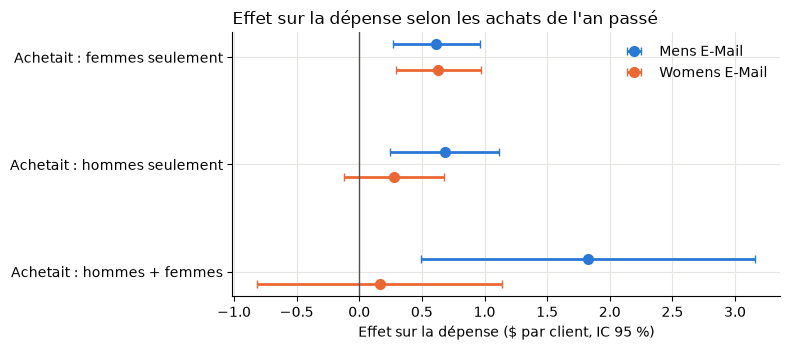

In [12]:
fig, ax = plt.subplots(figsize=(8, 3.6))
profils = ["femmes seulement", "hommes seulement", "hommes + femmes"]
for i, profil in enumerate(profils):
    for decalage, g in [(-0.12, "Mens E-Mail"), (0.12, "Womens E-Mail")]:
        r = effets_profil[(effets_profil["profil"] == profil) & (effets_profil["traitement"] == g)].iloc[0]
        ax.errorbar(r["effet ($)"], i + decalage, xerr=[[r["effet ($)"] - r["IC95 bas"]], [r["IC95 haut"] - r["effet ($)"]]],
                    fmt="o", color=COULEURS[g], markersize=7, capsize=3, linewidth=2,
                    label=g if i == 0 else None)
ax.axvline(0, color="#52514e", linewidth=1)
ax.set_yticks(range(len(profils)), [f"Achetait : {p}" for p in profils])
ax.invert_yaxis()
ax.set_xlabel("Effet sur la dépense ($ par client, IC 95 %)")
ax.set_title("Effet sur la dépense selon les achats de l'an passé", loc="left")
ax.legend(frameon=False, loc="upper right")
plt.tight_layout()
plt.savefig("../docs/figures/02_heterogeneite_profil.png", dpi=150)
plt.show()

In [13]:
# Test formel de l'interaction : l'effet de l'e-mail Femmes diffère-t-il selon `mens` ?
modele = smf.ols(f"spend ~ {formule_traitement} * mens", df).fit(cov_type="HC1")
terme = f"{formule_traitement}[T.Womens E-Mail]:mens"
print(f"Interaction e-mail Femmes × mens : {modele.params[terme]:+.3f} $  (p = {modele.pvalues[terme]:.3f})")
terme = f"{formule_traitement}[T.Mens E-Mail]:mens"
print(f"Interaction e-mail Hommes × mens : {modele.params[terme]:+.3f} $  (p = {modele.pvalues[terme]:.3f})")

Interaction e-mail Femmes × mens : -0.375 $  (p = 0.144)
Interaction e-mail Hommes × mens : +0.281 $  (p = 0.320)


**Lecture** : l'hétérogénéité a du sens métier.
- Chez les clients qui n'achetaient **que pour femmes**, les deux e-mails font jeu égal (≈ +0,62 $ chacun).
- Chez les clients qui achetaient **pour hommes** (seulement, ou hommes + femmes), l'e-mail Femmes a un effet faible et non distinguable de zéro, alors que l'e-mail Hommes reste efficace. Il atteint même +1,83 $ chez les acheteurs mixtes, le profil le plus actif (mais le plus petit, ≈ 2 100 clients par groupe, d'où un IC très large).

Les intervalles sont larges (sous-groupes plus petits, résultat rare), et le test d'interaction formel l'illustre : un écart visible à l'œil (−0,38 $) n'est pas significatif (p = 0,14).

⚠️ Découper en sous-groupes, c'est multiplier les tests (risque de *p-hacking*), et chaque sous-groupe a moins de puissance. Pour exploiter l'hétérogénéité **systématiquement** et sur **toutes** les covariables à la fois, il faut un modèle : c'est l'objet des **modèles d'uplift** (phase 4).

## Conclusion de la phase 2

| | E-mail Hommes vs aucun | E-mail Femmes vs aucun |
|---|---|---|
| Visite | **+7,7 pts** (10,6 % → 18,3 %) | **+4,5 pts** (→ 15,1 %) |
| Conversion | **+0,68 pt** (0,57 % → 1,25 %, ×2,2) | **+0,31 pt** (→ 0,88 %) |
| Dépense / client | **+0,77 $** [0,49 ; 1,05] | **+0,42 $** [0,17 ; 0,68] |

1. **Les deux e-mails ont un effet causal positif** sur les trois métriques. Les 9 comparaisons (dont Hommes vs Femmes) restent significatives après correction de Holm.
2. **L'e-mail Hommes domine** l'e-mail Femmes en moyenne : nettement sur la visite et la conversion, de justesse sur la dépense (p = 0,03).
3. **L'effet passe par le nombre d'acheteurs**, pas par le panier moyen (qui ne bouge pas significativement chez les acheteurs).
4. **Malgré une variable `spend` très asymétrique**, Welch et bootstrap donnent les mêmes intervalles : le théorème central limite tient à n ≈ 21 000.
5. **L'ajustement par covariables ne gagne presque rien** (erreur standard −0,1 à −1,4 %), car les covariables prédisent très mal le résultat à deux semaines.
6. **L'effet semble hétérogène** : l'e-mail Femmes n'a d'effet net que chez les clients « femmes seulement », où il égale l'e-mail Hommes ; l'e-mail Hommes agit partout. Les tests d'interaction ne sont pas significatifs pris un à un, mais la piste justifie de **modéliser l'effet individuel** et de **choisir quel e-mail envoyer à qui** (phases 4 et 5).

Les intervalles de confiance restent toutefois larges sur la conversion et la dépense. La phase 3 quantifie ce que cette expérience pouvait détecter.